In [74]:
import os
import sys
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

sys.path.insert(0, os.path.abspath('../'))
from helper_fct import resize_polygon, update_boundary

CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence_w25'
DX, DY   = 0.035, 0.035

In [75]:
# Position space (fixed DIIID params, same as opt_comp_convergence.py)
lim1              = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2,    delta=0.8, squar=0.15, npts=1700)
coil_center_cand1 = resize_polygon(lim1, dx=0.1)
lim2              = update_boundary(r0=1.94, z0=0, a0=0.95, kappa=1.55, delta=0.8, squar=0.15, npts=1700)
coil_center_cand2 = resize_polygon(lim2, dx=0.15)

inner       = coil_center_cand1[:len(coil_center_cand1) // 2]
outer       = coil_center_cand2[:len(coil_center_cand2) // 2]
theta_range = np.linspace(0, 180, len(inner))


def params_to_rz(params):
    """Convert [thetas..., radials...] to list of [R, Z] coil positions."""
    n       = len(params) // 2
    thetas  = params[:n]
    radials = params[n:]
    locs = []
    for theta, rho in zip(thetas, radials):
        R = (1 - rho) * np.interp(theta, theta_range, inner[:, 0]) + rho * np.interp(theta, theta_range, outer[:, 0])
        Z = (1 - rho) * np.interp(theta, theta_range, inner[:, 1]) + rho * np.interp(theta, theta_range, outer[:, 1])
        locs.append([R, Z])
    return locs


def draw_coils(ax, coil_locs, color, alpha=0.75):
    for R, Z in coil_locs:
        for z_sign in [1, -1]:
            ax.add_patch(plt.Rectangle(
                (R - DX, z_sign * Z - DY), 2*DX, 2*DY,
                facecolor=color, edgecolor='black', alpha=alpha, linewidth=0.6
            ))


def base_ax(ax, title=''):
    ax.plot(coil_center_cand1[:, 0], coil_center_cand1[:, 1], 'k--', alpha=0.3, linewidth=1)
    ax.plot(coil_center_cand2[:, 0], coil_center_cand2[:, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_aspect('equal')
    ax.set_xlabel('R [m]')
    ax.set_ylabel('Z [m]')
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.3)

print('Setup done')

Setup done


In [76]:
def iter_runs(conv_dir):
    entries = sorted(os.listdir(conv_dir))
    # flat: lambda:X,coils:Y directly under conv_dir
    # nested: numbered subdirs (e.g. 01/) then lambda:X,coils:Y
    if any(re.match(r'lambda:', e) for e in entries):
        roots = [conv_dir]
    else:
        roots = [os.path.join(conv_dir, e) for e in entries
                 if os.path.isdir(os.path.join(conv_dir, e))]

    for root in roots:
        for config in sorted(os.listdir(root)):
            if not re.match(r'lambda:', config):
                continue
            config_dir = os.path.join(root, config)
            for run_dir in sorted(os.listdir(config_dir)):
                rpath = os.path.join(config_dir, run_dir, 'results.json')
                if not os.path.isfile(rpath):
                    continue
                run_m = re.match(r'run_(\d+)', run_dir)
                run_idx = int(run_m.group(1)) if run_m else 0
                with open(rpath) as f:
                    yield config, run_idx, json.load(f)

runs = list(iter_runs(CONV_DIR))
print(f'Found {len(runs)} run(s)')


Found 3 run(s)



Config: lambda:1e-06,coils:4   run 01   bayes=1.8013e-03   lbfgs=1.5563e-03


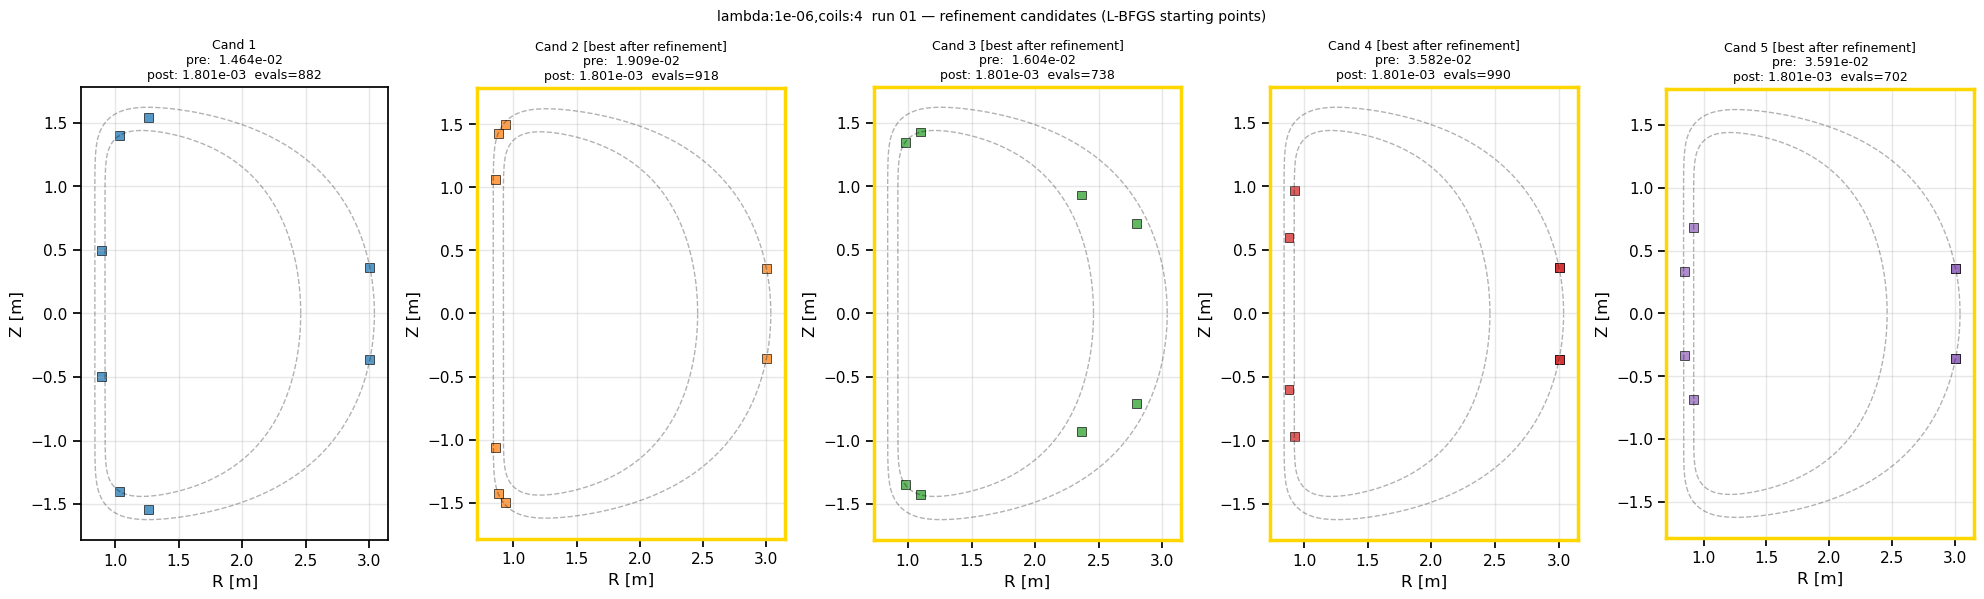

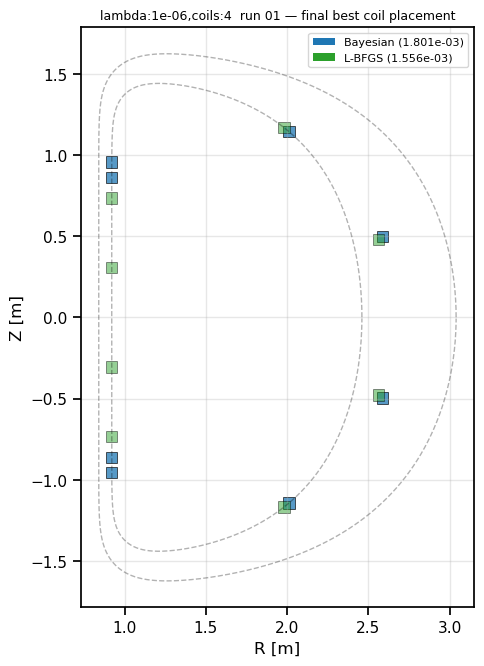


Config: lambda:1e-07,coils:4   run 01   bayes=5.3363e-05   lbfgs=5.3362e-05


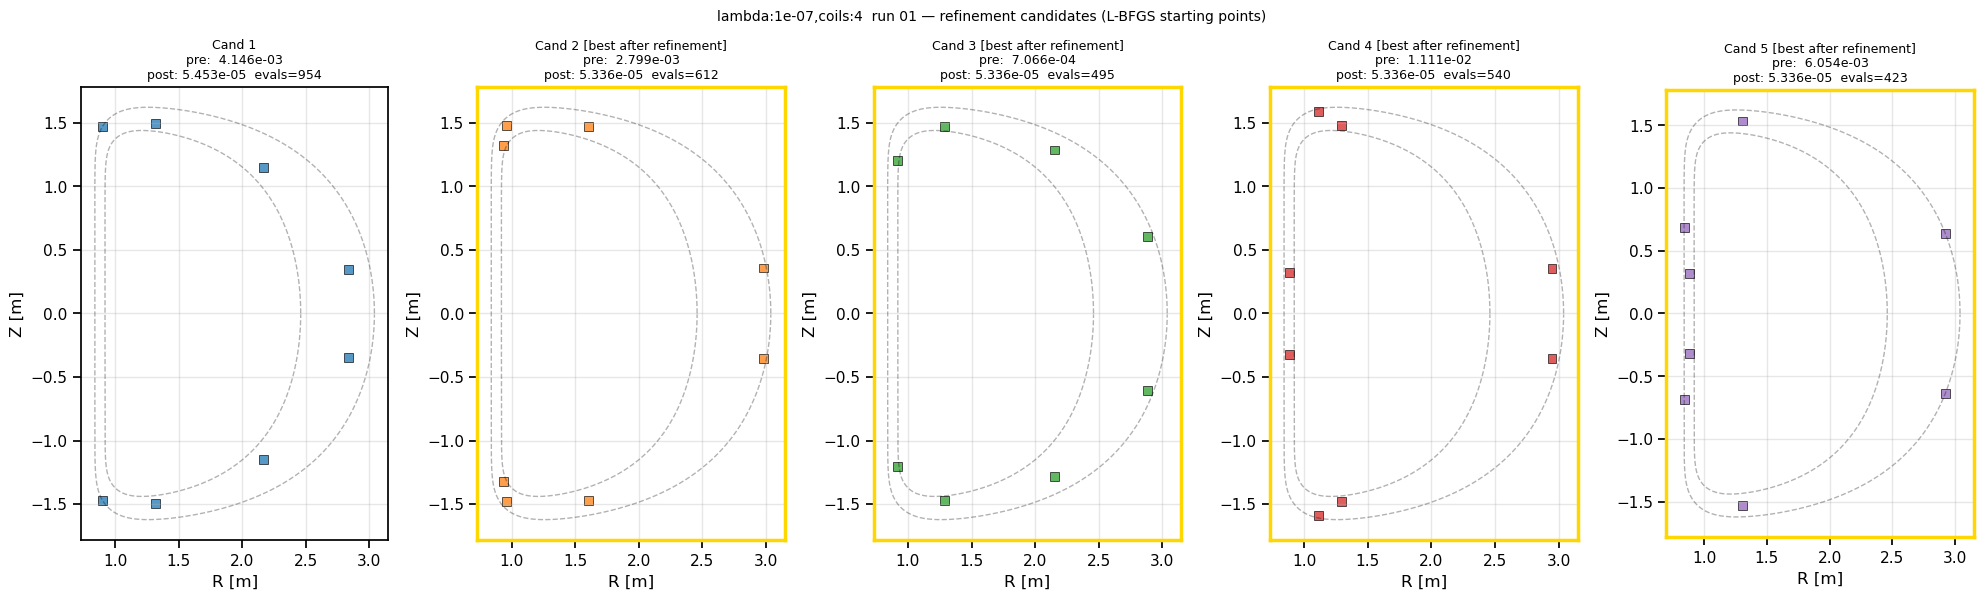

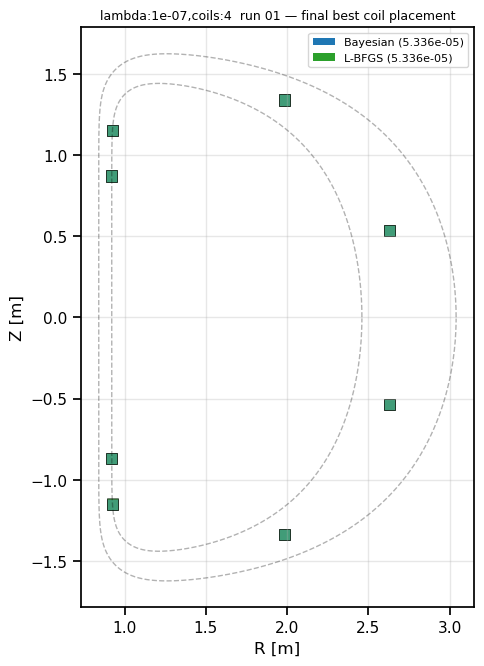


Config: lambda:1e-08,coils:4   run 01   bayes=8.1462e-06   lbfgs=8.1472e-06


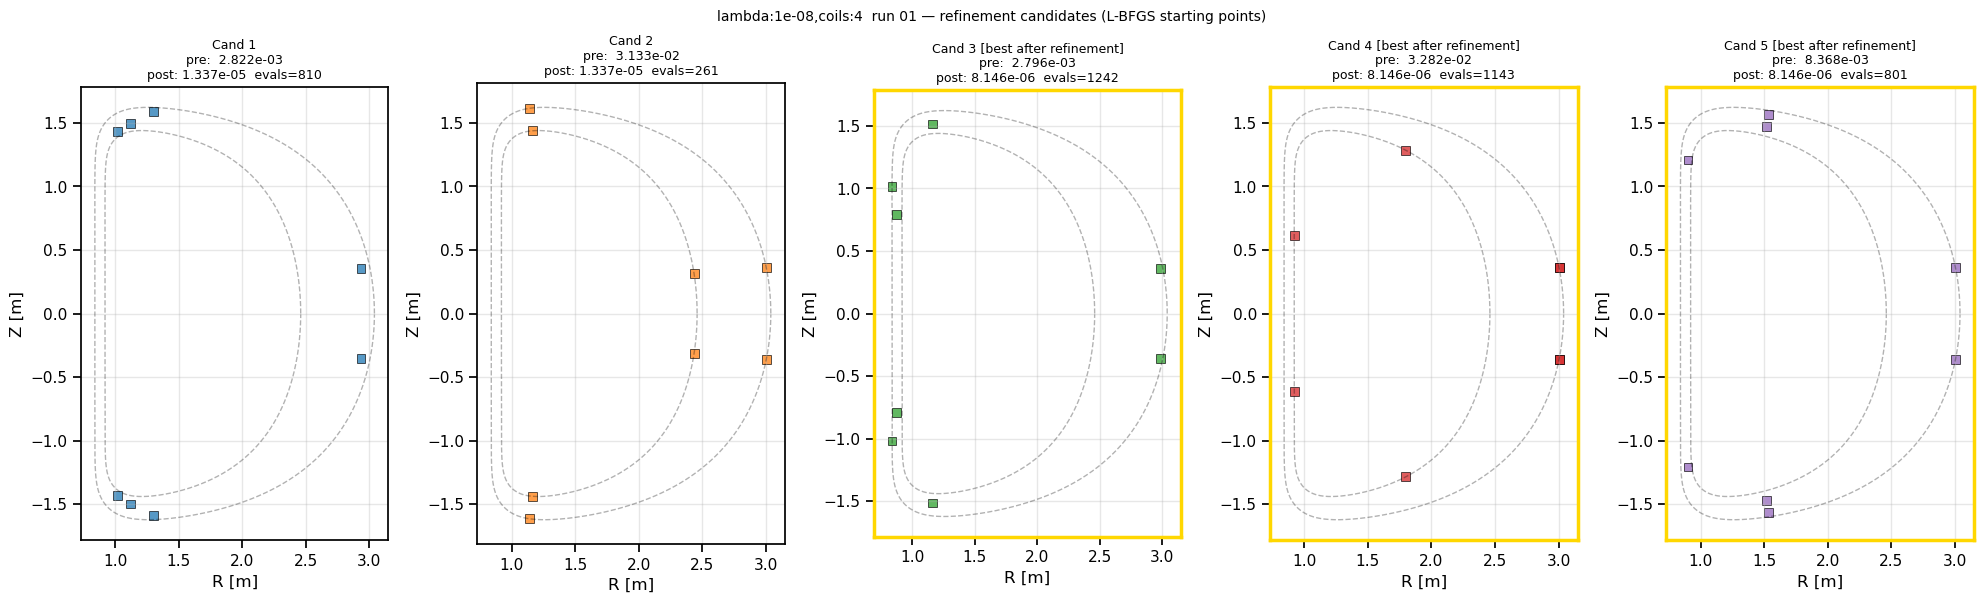

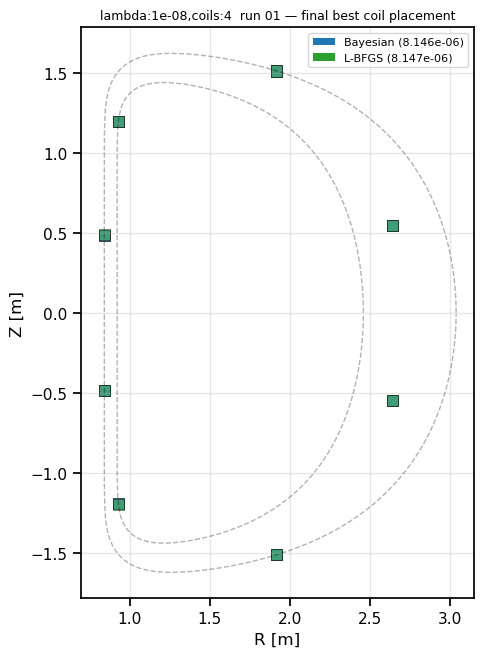

In [77]:
CMAP        = plt.cm.tab10
BAYES_COLOR = '#1f77b4'
LBFGS_COLOR = '#2ca02c'


def params_from_result(res):
    p       = res.get('parameters', {})
    thetas  = p.get('thetas', [])
    radials = p.get('radials', [])
    if not thetas:
        return None
    return thetas + radials


def prerefined_costs(bayes):
    """Return the cost at each candidate's starting point.

    L-BFGS-B always evaluates f(x0) first, so the first eval of each
    refinement run in cost_history is the pre-refinement cost.
    """
    n_bo         = bayes.get('n_bayesian_evals', 0)
    cost_history = bayes.get('cost_history', [])
    ref_evals    = bayes.get('refinement_evals', [])
    costs = []
    idx = n_bo
    for n in ref_evals:
        if idx < len(cost_history):
            costs.append(cost_history[idx])
        else:
            costs.append(float('nan'))
        idx += n
    return costs


for config, run_idx, data in runs:
    bayes = data['methods'].get('Bayesian', {})
    lbfgs = data['methods'].get('Multi-start L-BFGS', {})
    if not bayes:
        print(f'{config} run_{run_idx:02d}: no Bayesian data')
        continue

    candidates        = bayes.get('refinement_candidates', [])
    ref_costs         = bayes.get('refinement_costs', [])
    ref_evals         = bayes.get('refinement_evals', [])
    pre_costs         = prerefined_costs(bayes)
    bayes_best_cost   = bayes.get('best_cost', float('nan'))
    lbfgs_best_cost   = lbfgs.get('best_cost', float('nan'))
    bayes_best_params = params_from_result(bayes)
    lbfgs_best_params = params_from_result(lbfgs)

    print(f'\n{"="*65}')
    print(f'Config: {config}   run {run_idx:02d}   bayes={bayes_best_cost:.4e}   lbfgs={lbfgs_best_cost:.4e}')
    print(f'{"="*65}')

    # ----------------------------------------------------------------
    # 5 candidate coil placement plots
    # ----------------------------------------------------------------
    if not candidates:
        print('  refinement_candidates not saved (rerun with updated opt_comp_convergence.py)')
    else:
        best_ref_cost = min(ref_costs) if ref_costs else float('nan')
        ncols = min(len(candidates), 5)
        fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 6))
        if ncols == 1:
            axes = [axes]
        fig.suptitle(
            f'{config}  run {run_idx:02d} — refinement candidates (L-BFGS starting points)',
            fontsize=10
        )
        for i, (cand, ax) in enumerate(zip(candidates, axes)):
            coil_locs = params_to_rz(cand)
            pre_cost  = pre_costs[i] if i < len(pre_costs) else float('nan')
            post_cost = ref_costs[i] if i < len(ref_costs) else float('nan')
            evals     = ref_evals[i] if i < len(ref_evals) else '?'
            is_best   = (post_cost == best_ref_cost)
            title = (
                f'Cand {i+1}{" [best after refinement]" if is_best else ""}\n'
                f'pre:  {pre_cost:.3e}\n'
                f'post: {post_cost:.3e}  evals={evals}'
            )
            base_ax(ax, title=title)
            draw_coils(ax, coil_locs, color=CMAP(i))
            if is_best:
                for spine in ax.spines.values():
                    spine.set_edgecolor('gold')
                    spine.set_linewidth(2.5)
        plt.tight_layout()
        plt.show()

    # ----------------------------------------------------------------
    # Final best: Bayesian vs L-BFGS on one plot
    # ----------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5, 8))
    base_ax(ax, title=f'{config}  run {run_idx:02d} — final best coil placement')
    handles = []
    if bayes_best_params is not None:
        draw_coils(ax, params_to_rz(bayes_best_params), color=BAYES_COLOR)
        handles.append(plt.Rectangle((0,0), 1, 1, facecolor=BAYES_COLOR,
                                     label=f'Bayesian ({bayes_best_cost:.3e})'))
    if lbfgs_best_params is not None:
        draw_coils(ax, params_to_rz(lbfgs_best_params), color=LBFGS_COLOR, alpha=0.5)
        handles.append(plt.Rectangle((0,0), 1, 1, facecolor=LBFGS_COLOR,
                                     label=f'L-BFGS ({lbfgs_best_cost:.3e})'))
    ax.legend(handles=handles, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()